# Lab 5

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Questions

#### 1. Let’s say we have a fictional dataset of pairs of variables, a mother and her daughter’s heights. Create a CSV file for the above training data and write a Python function program to find the fitted linear regression with gradient descent technique. Compare the coefficients obtained from the sklearn model with your program. Compute the log loss, MSE and RMSE. Plot the graph Daughter height (Y-axis) vs Mother height (X-axis) with blue colour. Also, plot the line of best fit with red colour. Predict her daughter’s height with given a new mother height as 63. Plot the graph of error in y-axis and iteration in x-axis with 4 epochs (6x4=24 iterations).

In [115]:
data = {
    "mother_height": [58, 62, 60, 64, 67, 70],
    "daughter_height": [60, 60, 58, 60, 70, 72]
}
df = pd.DataFrame(data)
df.to_csv("height.csv", index=False)
df

,mother_height,daughter_height
0,58,60
1,62,60
2,60,58
3,64,60
4,67,70
5,70,72


In [116]:
df = pd.read_csv("height.csv")

X = df["mother_height"].values
y = df["daughter_height"].values

df

,mother_height,daughter_height
0,58,60
1,62,60
2,60,58
3,64,60
4,67,70
5,70,72


In [117]:
# gradient descent

m = 0
c = 0

errors = []

epochs = 4
lr = 0.0001

for epoch in range(epochs):
    for i in range(len(X)):
        y_pred = m * X[i] + c

        err = y[i] - y_pred

        m = m + lr * err * X[i]
        c = c + lr * err

        errors.append(err ** 2)

In [118]:
print(f"Slope: {m}")
print(f"Intercept: {c}")
print(f"\ny = {m}x + {c}")

Slope: 1.0149205396744159
Intercept: 0.016406249586034958

y = 1.0149205396744159x + 0.016406249586034958


In [119]:
# compare with sklearn

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X.reshape(-1, 1), y)

sklearn_m = model.coef_[0]
sklearn_c = model.intercept_

print("Gradient Descent:")
print(f"Slope: {m}")
print(f"Intercept: {c}")

print("\nSklearn:")
print(f"Slope: {sklearn_m}")
print(f"Intercept: {sklearn_c}")

Gradient Descent:
Slope: 1.0149205396744159
Intercept: 0.016406249586034958

Sklearn:
Slope: 1.2060301507537687
Intercept: -13.249581239530976


In [120]:
# error, MSE, RMSE

err = y - y_pred

mse = np.mean(err ** 2)
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MSE: 76.80043421317896
RMSE: 8.7635856938344


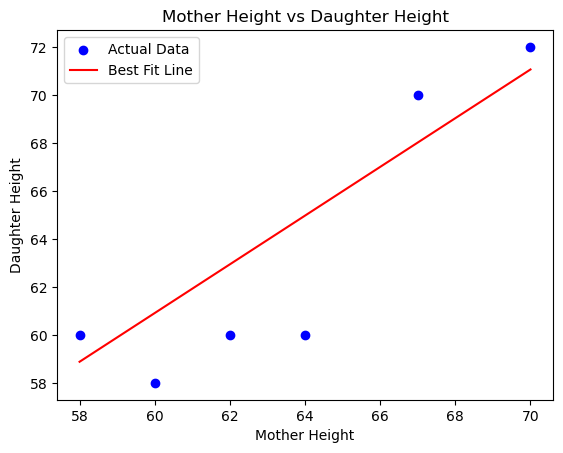

In [121]:
plt.scatter(X, y, color="blue", label="Actual Data")

X_line = np.linspace(X.min(), X.max(), 100)
y_line = m * X_line + c

plt.plot(X_line, y_line, color="red", label="Best Fit Line")

plt.xlabel("Mother Height")
plt.ylabel("Daughter Height")
plt.title("Mother Height vs Daughter Height")
plt.legend()

plt.show()

In [122]:
mother_height = 63
predicted_height = m * mother_height + c
print(f"Predicted Daughter Height: {predicted_height}")

Predicted Daughter Height: 63.956400249074235


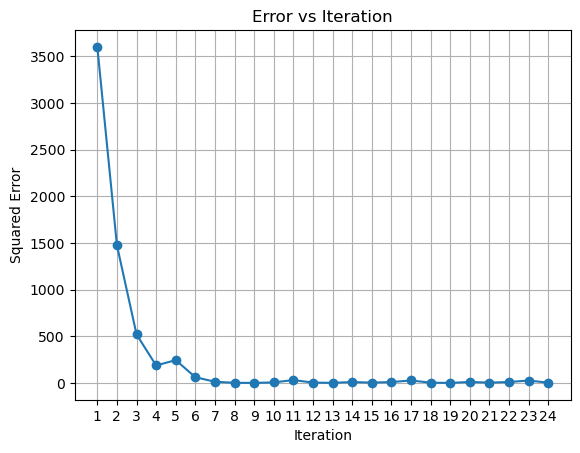

In [123]:
# error vs iteration

iterations = np.arange(1, len(errors) + 1)

plt.plot(iterations, errors, marker="o")

plt.xlabel("Iteration")
plt.ylabel("Squared Error")
plt.title("Error vs Iteration")

plt.xticks(iterations)
plt.grid()

plt.show()

#### 2. Create a CSV file for the above training data and write a Python function program to find the fitted logistic regression with gradient descent technique. Compare the coefficients obtained from the sklearn model with your program. Compute the predicted y and assign the class label (prediction = 0 IF p(fail) < 0.5 and prediction = 1 IF p(pass) >= 0.5) and compute the accuracy. Find the error for each iteration and predict the probability that a student will pass the exam if they study for 3.5 hours and 7.5 hours. Plot the graph of error in y-axis and iteration in x-axis with 3 epochs (8x3=24 iterations).

In [124]:
data = {
    "hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "pass":  [0, 0, 0, 0, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
df.to_csv("student_pass.csv", index=False)

df

,hours,pass
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1


In [125]:
df = pd.read_csv("student_pass.csv")

X = df["hours"].values
y = df["pass"].values

df

,hours,pass
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1


In [126]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [127]:
# gradient descent

m = 0
c = 0

errors = []

epochs = 3
lr = 0.1

for epoch in range(epochs):
    for i in range(len(X)):
        z = m * X[i] + c
        p = sigmoid(z)

        err = y[i] - p
        m = m + lr * err * X[i]
        c = c + lr * err

        log_loss = -(y[i] * np.log(p + 1e-15) + (1 - y[i]) * np.log(1 - p + 1e-15))

        errors.append(log_loss)

In [128]:
print(f"Slope: {m}")
print(f"Intercept: {c}")
print(f"\nz = {m:.4f}x + {c:.4f}")

Slope: 0.4730137971217938
Intercept: -0.2705761346120769

z = 0.4730x + -0.2706


In [129]:
z = m * X + c
predicted_probability = sigmoid(z)
predicted_probability

array([0.55043729, 0.66272276, 0.75923048, 0.83499901, 0.89036676,
       0.92874086, 0.9543715 , 0.97107042])

In [130]:
predicted_class = (predicted_probability >= 0.5).astype(int)
predicted_class

array([1, 1, 1, 1, 1, 1, 1, 1])

In [131]:
result = pd.DataFrame({
    "Hours": X,
    "Actual": y,
    "Probability": predicted_probability,
    "Predicted": predicted_class
})

result

,Hours,Actual,Probability,Predicted
0,1,0,0.550437,1
1,2,0,0.662723,1
2,3,0,0.759230,1
3,4,0,0.834999,1
4,5,1,0.890367,1
5,6,1,0.928741,1
6,7,1,0.954371,1
7,8,1,0.971070,1


In [132]:
accuracy = np.mean(y == predicted_class)

print(f"Accuracy = {accuracy} ({accuracy * 100}%)")

Accuracy = 0.5 (50.0%)


In [133]:
# compare with sklearn

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty=None)

model.fit(X.reshape(-1, 1), y)

sklearn_m = model.coef_[0][0]
sklearn_c = model.intercept_[0]

print("Gradient Descent:")
print(f"Slope: {m}")
print(f"Intercept: {c}")

print("\nSklearn:")
print(f"Slope: {sklearn_m}")
print(f"Intercept: {sklearn_c}")

Gradient Descent:
Slope: 0.4730137971217938
Intercept: -0.2705761346120769

Sklearn:
Slope: 22.797279606591243
Intercept: -101.96495028315418


In [134]:
hours = 3.5
prob3_5 = sigmoid(m * hours + c)
print(f"Probability of passing for 3.5 hours: {prob3_5}")

if prob3_5 >= 0.5:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Probability of passing for 3.5 hours: 0.7997883631536821
Prediction: Pass


In [135]:
hours = 7.5
prob7_5 = sigmoid(m * hours + c)
print(f"Probability of passing for 7.5 hours: {prob7_5}")

if prob7_5 >= 0.5:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Probability of passing for 7.5 hours: 0.9636322499400057
Prediction: Pass


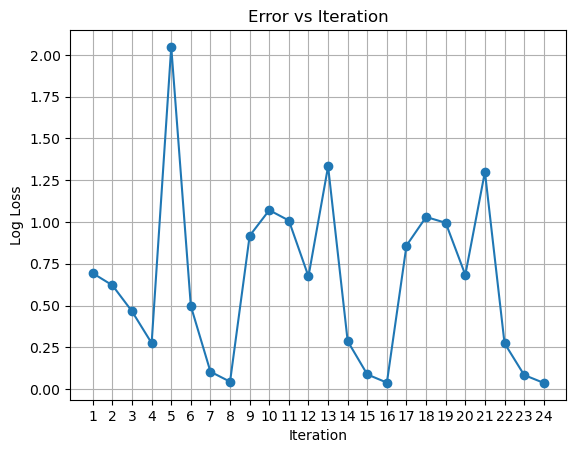

In [136]:
# error vs iteration

iterations = np.arange(1, len(errors) + 1)

plt.plot(iterations, errors, marker="o")

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Error vs Iteration")

plt.xticks(iterations)
plt.grid()

plt.show()

#### 3. Consider the above dataset with two independent variables (X1 and X2) and a dependent variable (Y). Implement in Python, how you can perform the logistic regression to model the relationship between the independent variables and the dependent variable.

In [137]:
data = {
    "X1": [4, 2, 1, 3, 1, 6],
    "X2": [1, 8, 0, 2, 4, 7],
    "Y":  [2, -14, 1, -1, -7, -8]
}

df = pd.DataFrame(data)
df.to_csv("multiple_regression.csv", index=False)

df

,X1,X2,Y
0,4,1,2
1,2,8,-14
2,1,0,1
3,3,2,-1
4,1,4,-7
5,6,7,-8


In [138]:
df = pd.read_csv('multiple_regression.csv')
df

,X1,X2,Y
0,4,1,2
1,2,8,-14
2,1,0,1
3,3,2,-1
4,1,4,-7
5,6,7,-8


In [139]:
X = df[["X1", "X2"]]
y = df["Y"]

In [140]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient of X1: {model.coef_[0]}")
print(f"Coefficient of X2: {model.coef_[1]}")

Intercept: -8.881784197001252e-16
Coefficient of X1: 1.0000000000000002
Coefficient of X2: -2.0


In [141]:
y_pred = model.predict(X)

result = df.copy()
result["Predicted_Y"] = y_pred

result

,X1,X2,Y,Predicted_Y
0,4,1,2,2.0
1,2,8,-14,-14.0
2,1,0,1,1.0
3,3,2,-1,-1.0
4,1,4,-7,-7.0
5,6,7,-8,-8.0


In [142]:
err = y - y_pred

mse = np.mean(err ** 2)
rmse = np.sqrt(mse)

result["Error"] = err

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

result

MSE: 3.4512664603419266e-31
RMSE: 5.874748045952207e-16


,X1,X2,Y,Predicted_Y,Error
0,4,1,2,2.0,0.000000e+00
1,2,8,-14,-14.0,0.000000e+00
2,1,0,1,1.0,6.661338e-16
3,3,2,-1,-1.0,2.220446e-16
4,1,4,-7,-7.0,8.881784e-16
5,6,7,-8,-8.0,-8.881784e-16


In [143]:
b0 = model.intercept_
b1 = model.coef_[0]
b2 = model.coef_[1]

print(f"y = {b0:.4f} + ({b1:.4f})x1 + ({b2:.4f})x2")

y = -0.0000 + (1.0000)x1 + (-2.0000)x2


In [144]:
Xm = np.column_stack((
    np.ones(len(df)),
    df["X1"],
    df["X2"]
))

y_matrix = df["Y"].values

beta = np.linalg.inv(Xm.T @ Xm) @ Xm.T @ y_matrix

print(f"Intercept: {beta[0]}")
print(f"Coefficient of X1: {beta[1]}")
print(f"Coefficient of X2: {beta[2]}")

Intercept: 9.048317650695026e-15
Coefficient of X1: 0.9999999999999967
Coefficient of X2: -2.0000000000000004


In [145]:
comparison = pd.DataFrame({
    "Coefficient": ["Intercept", "X1", "X2"],
    "Matrix Method": [beta[0], beta[1], beta[2]],
    "sklearn": [model.intercept_, model.coef_[0], model.coef_[1]]
})

comparison

,Coefficient,Matrix Method,sklearn
0,Intercept,9.048318e-15,-8.881784e-16
1,X1,1.000000e+00,1.000000e+00
2,X2,-2.000000e+00,-2.000000e+00


## Additional Questions

#### 1. Write a Python program for SGD by considering the year wise gold and silver price data. Compare the coefficients obtained from sklearn model with your program. Compute the error, MSE and RMSE. Predict the gold price with the year 2025 for 1 gram and, gold and silver price with the year 2024 for 1 gram.

In [146]:
gold = pd.read_csv('gold.csv')
silver = pd.read_csv('silver.csv')

In [147]:
Xg = gold['year'].values
yg = gold['price'].values

Xg_s = Xg - Xg.min()

In [148]:
mg = 0
cg = 0

lr_g = 0.0001
epochs = 1000

errors_g = []

for epoch in range(epochs):
    for i in range(len(Xg_s)):
        y_pred = mg * Xg_s[i] + cg

        err_g = yg[i] - y_pred

        mg = mg + lr_g * err_g * Xg_s[i]
        cg = cg + lr_g * err_g

        errors_g.append(err_g)

print(f"Slope: {mg}")
print(f"Intercept: {cg}")

Slope: 967.9471461110883
Intercept: -9142.693346261536


In [149]:
gold_model = LinearRegression()
gold_model.fit(Xg_s.reshape(-1, 1), yg)

print(f"Slope: {gold_model.coef_[0]}")
print(f"Intercept: {gold_model.intercept_}")

Slope: 674.7124488603156
Intercept: -9164.63237872589


In [150]:
gold_comparison = pd.DataFrame({
    "Method": ["SGD", "Sklearn"],
    "Slope": [mg, gold_model.coef_[0]],
    "Intercept": [cg, gold_model.intercept_]
})

gold_comparison

,Method,Slope,Intercept
0,SGD,967.947146,-9142.693346
1,Sklearn,674.712449,-9164.632379


In [151]:
gold_pred = mg * Xg_s + cg

gold_error = yg - gold_pred

mse_g = np.mean(gold_error ** 2)
rmse_g = np.sqrt(mse_g)

print(f"MSE: {mse_g}")
print(f"RMSE: {rmse_g}")

MSE: 156660610.046774
RMSE: 12516.413625586763


In [152]:
year = 2025
year_scaled = year - Xg.min()
gold_2025 = mg * year_scaled + cg

print(f"Predicted Gold Price for 2025 (1g): {gold_2025 / 10}")

Predicted Gold Price for 2025 (1g): 4893.413542040376


In [153]:
Xs = silver['year'].values
ys = silver['price'].values

Xs_s = Xs - Xs.min()

In [154]:
ms = 0
cs = 0

lr_s = 0.0001
epochs = 1000

errors_s = []

for epoch in range(epochs):
    for i in range(len(Xs_s)):
        y_pred = ms * Xs_s[i] + cs
        err_s = ys[i] - y_pred

        ms = ms + lr_s * err_s * Xs_s[i]
        cs = cs + lr_s * err_s

        errors_s.append(err_s)

print(f"Slope: {ms}")
print(f"Intercept: {cs}")

Slope: 1435.7670150008894
Intercept: -5655.805496687615


In [155]:
silver_model = LinearRegression()
silver_model.fit(Xs_s.reshape(-1, 1), ys)

print(f"Slope: {silver_model.coef_[0]}")
print(f"Intercept: {silver_model.intercept_}")

Slope: 1388.7457256300138
Intercept: -8045.596899224805


In [156]:
silver_comparison = pd.DataFrame({
    "Method": ["SGD", "Sklearn"],
    "Slope": [ms, silver_model.coef_[0]],
    "Intercept": [cs, silver_model.intercept_]
})

silver_comparison

,Method,Slope,Intercept
0,SGD,1435.767015,-5655.805497
1,Sklearn,1388.745726,-8045.596899


In [157]:
silver_pred = ms * Xs_s + cs

silver_error = ys - silver_pred

mse_s = np.mean(silver_error ** 2)
rmse_s = np.sqrt(mse_s)

print(f"MSE: {mse_s}")
print(f"RMSE: {rmse_s}")

MSE: 106272205.03708589
RMSE: 10308.841110284215


In [158]:
year = 2024
year_scaled = year - Xs.min()
silver_2024 = ms * year_scaled + cs

print(f"Predicted Silver Price for 2024 (1g): {silver_2024 / 1000}")

Predicted Silver Price for 2024 (1g): 56.08217614835063


In [159]:
year = 2024
year_scaled = year - Xg.min()
gold_2024 = mg * year_scaled + cg

print(f"Predicted Gold Price for 2024 (1g): {gold_2024 / 10}")

Predicted Gold Price for 2024 (1g): 4796.618827429267


#### 2. Suppose you have a gold/silver price dataset with a single independent variable (X) and a dependent variable (Y). You want to fit a logistic regression model to this data. Develop an example code snippet in Python.

In [160]:
df = pd.read_csv('gold.csv')
df.head()

,year,price
0,1965,72
1,1966,84
2,1967,103
3,1968,162
4,1969,176


In [161]:
threshold = df[['price']].median()

df['class'] = (df[['price']] >= threshold).astype(int)
df.head()

,year,price,class
0,1965,72,0
1,1966,84,0
2,1967,103,0
3,1968,162,0
4,1969,176,0


In [162]:
X = df[['year']]
y = df[['class']]

model = LogisticRegression()
model.fit(X, y)

print(f"Coefficient: {model.coef_[0][0]}")
print(f"Intercept: {model.intercept_[0]}")

Coefficient: 0.5044997193129793
Intercept: -1005.720189928572


/usr/lib/python3/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [163]:
probs = model.predict_proba(X)[:, 1]
probs

array([5.69650941e-07, 9.43430910e-07, 1.56246852e-06, 2.58769017e-06,
       4.28561331e-06, 7.09762754e-06, 1.17547292e-05, 1.94675241e-05,
       3.22408600e-05, 5.33947890e-05, 8.84270432e-05, 1.46440549e-04,
       2.42505206e-04, 4.01562741e-04, 6.64875665e-04, 1.10065816e-03,
       1.82154693e-03, 3.01316588e-03, 4.98042822e-03, 8.22150253e-03,
       1.35430379e-02, 2.22318339e-02, 3.62900190e-02, 5.87041021e-02,
       9.36171483e-02, 1.46071842e-01, 2.20758997e-01, 3.19352497e-01,
       4.37269938e-01, 5.62730319e-01, 6.80647730e-01, 7.79241182e-01,
       8.53928288e-01, 9.06382940e-01, 9.41295956e-01, 9.63710017e-01,
       9.77768189e-01, 9.86456976e-01, 9.91778506e-01, 9.95019577e-01,
       9.96986837e-01, 9.98178455e-01, 9.98899343e-01, 9.99335125e-01,
       9.99598438e-01, 9.99757495e-01, 9.99853560e-01, 9.99911573e-01,
       9.99946605e-01, 9.99967759e-01, 9.99980532e-01, 9.99988245e-01,
       9.99992902e-01, 9.99995714e-01, 9.99997412e-01, 9.99998438e-01,
      

In [164]:
pred_class = model.predict(X)
pred_class

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

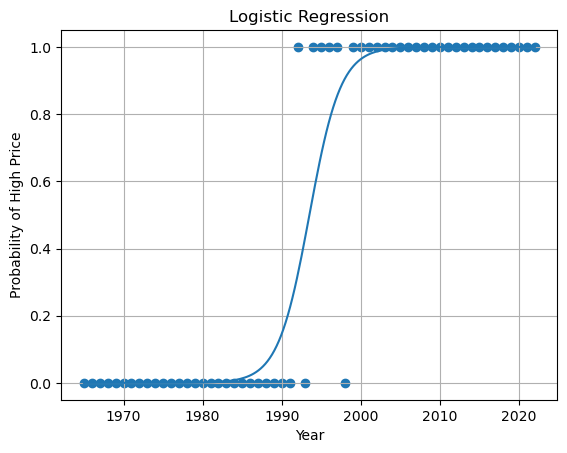

In [165]:
X_plot = np.linspace(df['year'].min(), df['year'].max(), 200)

X_plot_df = pd.DataFrame({
    'year': X_plot
})

y_plot = model.predict_proba(X_plot_df)[:, 1]

plt.scatter(df['year'], df['class'])
plt.plot(X_plot, y_plot)

plt.xlabel("Year")
plt.ylabel("Probability of High Price")
plt.title("Logistic Regression")

plt.grid()
plt.show()

In [166]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

y_pred = model.predict(X)
y_prob = model.predict_proba(X)[:, 1]

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
loss = log_loss(y, y_prob)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Log Loss: {loss}")

Accuracy: 0.9655172413793104
Precision: 0.9655172413793104
Recall: 0.9655172413793104
F1 Score: 0.9655172413793104
Log Loss: 0.10804312060090737


#### 3. Consider the gold and/or silver price  dataset  and to evaluate a logistic regression model using ROC and AUC:
1. Calculate predicted probabilities for each instance in the test set. 
2. Plot the ROC curve using the True Positive Rate (Sensitivity) and False Positive Rate. 
3. Calculate the AUC to summarize the model's performance.

In [170]:
df = pd.read_csv('silver.csv')
df.head()

,year,price
0,1981,2715
1,1982,2720
2,1983,3105
3,1984,3570
4,1985,3955


In [171]:
threshold = df['price'].median()
df['class'] = (df['price'] >= threshold).astype(int)

df.head()

,year,price,class
0,1981,2715,0
1,1982,2720,0
2,1983,3105,0
3,1984,3570,0
4,1985,3955,0


In [172]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [173]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/lib/python3/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [174]:
y_prob = model.predict_proba(X_test)[:, 1]
y_prob

array([9.99994260e-01, 7.99618611e-04, 1.55919637e-05, 2.55086132e-05,
       9.29239148e-03, 9.90841889e-01, 9.99999199e-01, 9.99518218e-01,
       9.99997855e-01, 9.99212034e-01, 1.51132763e-02, 1.11691580e-04])

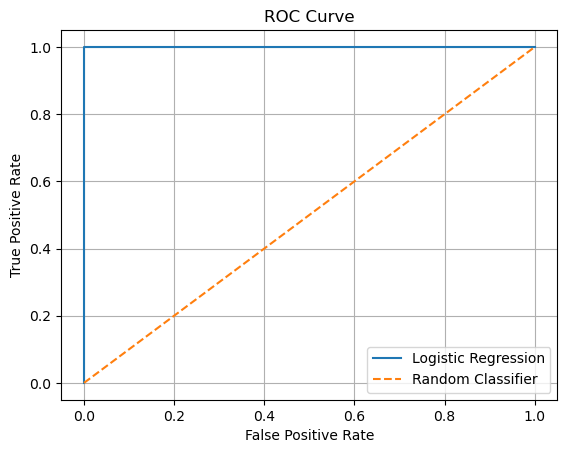

In [175]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [176]:
auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc}")

AUC: 1.0
